In [ ]:
library(tidyverse)
library(scales)
library(glmnet)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   4.0.1     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor


Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-10



In [2]:

df <- read_delim("https://raw.githubusercontent.com/wend1k3/CWL2-STAT-301/main/marketing_campaign.csv", 
                 delim = "\t") 

Rows: 2240 Columns: 29
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (3): Education, Marital_Status, Dt_Customer
dbl (26): ID, Year_Birth, Income, Kidhome, Teenhome, Recency, MntWines, MntF...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## (0) Title Page
Name: Wendi Ke
Group Number and Name: G11-CWL2
Group Member: CC Liang, Jinghan Zhang and Bowen Cui


## (1)  Data Description--Individual assignment 1


### (1) Dataset Description

This dataset contains marketing campaign data that tracks customer demographics, purchasing behavior, and response to marketing campaigns. The data includes information about customers' education, marital status, income, household composition, purchasing patterns across different product categories (wine, fruits, meat, fish, sweets, and gold products), and their responses to various marketing campaigns over the last 2 years.

There are 2240 observations with 29 variables.

#### a) Number of Observations and Variables

In [3]:
n_obs <- nrow(df)
n_vars <- ncol(df)

cat("Number of observations:", n_obs, "\n")
cat("Number of variables:", n_vars, "\n")


Number of observations: 2240 
Number of variables: 29 


#### b) Variable Names and Types

In [4]:
variable_info <- tibble(
  Variable_Name = names(df),
  Data_Type = sapply(df, class)
)
variable_info 

Variable_Name,Data_Type
<chr>,<chr>
ID,numeric
Year_Birth,numeric
Education,character
Marital_Status,character
Income,numeric
Kidhome,numeric
Teenhome,numeric
Dt_Customer,character
Recency,numeric


#### c) Data Collection Process

Based on the available information, the data collection process is not explicitly documented. I will assume the following:

- **Sampling Method**: This appears to be a complete dataset of all customers who were enrolled with the company during the observation period and were targeted by at least one marketing campaign. This is observational data, not from a controlled experiment.

- **IID Assumption (Independent and Identically Distributed)**: 
  - **Independence**: I  assume that each customer's behavior and campaign response is independent of other customers. This means one customer's decision to accept or reject a campaign does not influence another customer's decision.
  - **Identically Distributed**: We assume all customers are drawn from the same underlying population and follow the same data-generating process.
  - **Potential Violations to Consider**: 
    - Customers within the same household may not be independent (e.g., married couples making joint purchasing decisions)
    - Temporal effects may exist if customers enrolled at different times or if campaigns occurred sequentially over time
    - Word-of-mouth or social network effects could introduce dependence between customers
  - Despite these potential violations, for the purposes of this analysis, I will proceed with the IID assumption as a reasonable approximation.


#### d) Data Source and Citation

Data Source: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis/data

Acknowledgement: The dataset for this project is provided by Dr. Omar Romero-Hernandez.

## (1) Methods and Plan-- Individual Assignment 2

### b) Proposed Method

**Method**: LASSO Poisson Regression with Forward Selection Comparison and Post-LASSO Refitting

**Why This Method is Appropriate**:

LASSO Poisson regression is chosen because our response variable, `NumCatalogPurchases`, is a **count variable** (non-negative integers), and we have many potential predictors. LASSO combines the Poisson regression framework for count data with L1 regularization for automatic variable selection and improved prediction performance.

**Why This Method Was Chosen**:

1. **Nature of Response Variable**: Counts of catalog purchases (0, 1, 2, ...) require Poisson regression rather than linear regression, which could predict negative values.

2. **Prediction Focus with Many Predictors**: With numerous demographic, spending, and behavioral variables, LASSO is ideal because it reduces overfitting through regularization and automatically selects relevant predictors.

3. **Handles Multicollinearity**: Product spending variables are highly correlated. LASSO handles this by selecting among correlated predictors.

4. **Validation Strategy**: 
   - **Three-way split of training data**: 20% for LASSO training, 20% for forward selection training, 20% for validation
   - **Independent test set**: 40% held out for final evaluation
   - **Comparison approach**: LASSO vs. Forward stepwise selection (AIC-based) to determine best variable selection method
   - **Post-LASSO refitting**: After LASSO selects variables, we refit using standard Poisson GLM without penalty to obtain unbiased coefficient estimates for inference
   - This design prevents information leakage and provides fair comparison between methods

5. **Handles Zero Counts**: Like standard Poisson regression, LASSO naturally accommodates customers with zero catalog purchases.

**Model Specification**:

Predictors include demographics (Age, Income, Education, Marital_Status), household composition (Kidhome, Teenhome), spending patterns (individual product categories), channel usage (NumWebPurchases, NumStorePurchases, NumDealsPurchases), and customer engagement (Recency, NumWebVisitsMonth, Total_Campaigns_Accepted).

The LASSO minimizes: -log-likelihood + λ Σ|βⱼ|

where λ is selected via 10-fold cross-validation on the LASSO training set.

### c) Assumptions and Limitations

**Required Assumptions**:

1. **Count Response Variable**: 
   - **Assumption**: The response variable `NumCatalogPurchases` should be a count (non-negative integers).
   - **Status**: This assumption is satisfied - the variable represents discrete counts of purchases.

2. **Independence of Observations**:
   - **Assumption**: Each customer's catalog purchase behavior should be independent of others.
   - **Potential Violation**: Customers in the same household (e.g., married couples) may not be truly independent. Word-of-mouth effects or temporal trends in marketing campaigns could also introduce dependencies.
   - **Impact**: For inference, violations would affect standard errors and significance tests. For prediction (our focus), this is less critical as we evaluate performance on held-out data where similar dependencies would exist.

3. **Mean-Variance Equality (Equidispersion)**:
   - **Assumption**: Poisson regression assumes the mean equals the variance ($E[Y] = Var[Y]$).
   - **Potential Violation**: **Overdispersion** is common in real-world count data, where variance exceeds the mean. This occurs when there is more variability in catalog purchases than the Poisson model assumes (e.g., due to unobserved heterogeneity among customers).
   - **Impact**: If overdispersion exists, standard errors will be underestimated, and we may incorrectly identify predictors as significant. We will check for overdispersion after fitting the model.

4. **No Perfect Multicollinearity**:
   - **Assumption**: Predictor variables should not be perfectly correlated.
   - **Potential Issue**: Product category spending variables (MntWines, MntMeat, etc.) are correlated by construction.
   - **LASSO Advantage**: LASSO regression naturally handles multicollinearity by shrinking coefficients and selecting among correlated predictors, making this less of a concern for our prediction-focused approach.

**Limitations and Weaknesses**:

1. **Overdispersion Limitation**: 
   - The Poisson model assumes mean equals variance. If overdispersion is present (variance > mean), predictions may be suboptimal.
   - **Solution**: For prediction-focused models, we evaluate this through cross-validation performance metrics (MAE, RMSE) on the test set. 

2. **Zero-Inflation**:
   - If many customers have zero catalog purchases, and these zeros arise from two distinct processes (e.g., some customers never consider catalogs vs. some consider but don't purchase), a Zero-Inflated Poisson model might be more appropriate.
   - We will examine the proportion and distribution of zeros in the response variable.

### Methods and Plan

## (2) Question -- Individual Assignment 1

### a)  Question

**What customer characteristics and behavioral patterns drive catalog shopping behavior, and can we build a model to predict the number of catalog purchases a customer will make based on their demographics, income, spending habits, and engagement across other purchase channels?**

This question explores the complex relationship between multiple customer attributes and their catalog purchasing frequency. Rather than focusing on a simple bivariate relationship, we examine how demographic factors (income, education, age, household composition), spending patterns across six product categories (wine, fruits, meat, fish, sweets, and gold), engagement with other channels (web and store purchases), marketing campaign responsiveness, and customer characteristics collectively influence catalog shopping behavior. 

### b) Focus: Prediction vs. Inference

This question focuses on **both prediction and inference**:

- **Prediction**: We aim to build a model that can accurately predict how many catalog purchases a customer will make, enabling the company to estimate future catalog channel revenue and identify high-value catalog shoppers for targeted promotions


- **Inference**: We also want to understand which factors are statistically significant drivers of catalog purchasing behavior, allowing us to identify customer segments most receptive to catalog marketing


### c) Response Variable

**Response Variable**: `NumCatalogPurchases` (number of purchases made using a catalogue)

This variable represents the number of purchases a customer made through the company's catalog during the observation period. It is a **count variable** (non-negative integer), making it suitable for count-based regression models such as Poisson regression with assumption that  the mean equals the variance



### d) Most Important Covariates (Predictors)

The following covariates might be most important in predicting catalog purchase count:
1. **Age** 

2. **Income** (Customer's yearly household income): 
   - Higher-income customers may have more leisure time to browse catalogs
   - Income may interact with age - affluent older customers may be prime catalog shoppers
   - Lower-income customers might prefer in-store shopping for deals

3. **Other Purchase Channel Usage**:
   - `NumWebPurchases`: Customers who prefer online shopping may use catalogs less (substitution effect) or more (complementary browsing)
   - `NumStorePurchases`: Frequent store shoppers might have different catalog usage patterns
   - Understanding channel preferences helps identify catalog-specific segments

4. **Total Spending** (sum across all product categories): 
   - High-spending customers are more valuable catalog recipients
   - Spending level indicates overall engagement and purchasing capacity
   - May need to control for total purchases to isolate catalog preference


### e) Role of Other Variables

Other variables in the dataset might play important supporting roles in the analysis:

**Product Category Spending** (Control for Product Preferences):
- `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds`: 
  - Specific product preferences may drive channel choice (e.g., wine buyers might prefer catalog browsing for selection)
  - Helps distinguish catalog preference from overall spending level
  - Can identify which product categories drive catalog purchases


**Interaction Effects to Explore**:
- **Age × Education**: Older, educated customers might be a unique catalog segment
- **Total_Spending × Catalog_Purchases**: Does the relationship between spending and catalog use change at different spending levels?



## (3) Exploratory Data Analysis and Visualization -- Individual Assignment 1



### (a) load dataset and (b) clean/wrangle the data already done in (1)

### (c) missing values
There are 24 missing values for variable `Income`. There aren't any variables with a large proportion of missing data.

In [5]:
colSums(is.na(df))

ID          Year_Birth           Education      Marital_Status 
                  0                   0                   0                   0 
             Income             Kidhome            Teenhome         Dt_Customer 
                 24                   0                   0                   0 
            Recency            MntWines           MntFruits     MntMeatProducts 
                  0                   0                   0                   0 
    MntFishProducts    MntSweetProducts        MntGoldProds   NumDealsPurchases 
                  0                   0                   0                   0 
    NumWebPurchases NumCatalogPurchases   NumStorePurchases   NumWebVisitsMonth 
                  0                   0                   0                   0 
       AcceptedCmp3        AcceptedCmp4        AcceptedCmp5        AcceptedCmp1 
                  0                   0                   0                   0 
       AcceptedCmp2            Complain       Z_CostContact           Z_Revenue 
                  0                   0                   0                   0 
           Response 
                  0

In [6]:
df <- df %>% drop_na()

### (d) class imbalance
We need to find the categorical variables in the dataset first:
- categorical variables: `Education`, `Marital_Status`
- binary numeric variables:  `AcceptedCmp1`, `AcceptedCmp2`, `AcceptedCmp3`, `AcceptedCmp4`, `AcceptedCmp5`, `Response`, `Complain`


In [7]:
categorical_vars <- df %>%
  select(where(is.character)) %>%
  names()
cat("Categorical variables in the dataset:\n")
print(categorical_vars)

binary_vars <- c("AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", 
                 "AcceptedCmp5", "Response", "Complain")
cat("\n\nBinary categorical variables (numeric coded):\n")
print(binary_vars)

Categorical variables in the dataset:
[1] "Education"      "Marital_Status" "Dt_Customer"   


Binary categorical variables (numeric coded):
[1] "AcceptedCmp1" "AcceptedCmp2" "AcceptedCmp3" "AcceptedCmp4" "AcceptedCmp5"
[6] "Response"     "Complain"    


In [8]:

check_imbalance <- function(variable_name) {
  cat("\n===", variable_name, "===\n")
  

  freq_table <- table(df[[variable_name]])

  
  # Proportions
  prop_table <- prop.table(freq_table)
  print(round(prop_table * 100, 2))
  
}
categorical_vars <- categorical_vars[categorical_vars!="Dt_Customer"]

for (var in categorical_vars) {
  check_imbalance(var)
}


=== Education ===

  2n Cycle      Basic Graduation     Master        PhD 
      9.03       2.44      50.36      16.47      21.71 

=== Marital_Status ===

  Absurd    Alone Divorced  Married   Single Together    Widow     YOLO 
    0.09     0.14    10.47    38.67    21.25    25.86     3.43     0.09 


It is trivial that the class 'Graduation' in `Education` makes up a large majority of the observations. Thus, there is class imbalance in `Education`.
Also, in each following binary numeric class,there is class imbalance.

In [9]:
binary_vars <- c("AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", 
                 "AcceptedCmp5", "Response", "Complain")

for (var in binary_vars) {
  cat("\n===", var, "===\n")
  freq <- table(df[[var]])
  prop <- prop.table(freq)
  print(round(prop * 100, 2))
}


=== AcceptedCmp1 ===

    0     1 
93.59  6.41 

=== AcceptedCmp2 ===

    0     1 
98.65  1.35 

=== AcceptedCmp3 ===

    0     1 
92.64  7.36 

=== AcceptedCmp4 ===

   0    1 
92.6  7.4 

=== AcceptedCmp5 ===

    0     1 
92.69  7.31 

=== Response ===

    0     1 
84.97 15.03 

=== Complain ===

    0     1 
99.05  0.95 


### (e) Visualization and Explanation
This visualization directly addresses our research question by simultaneously showing how five key variables relate to catalog shopping: age and income (our top demographic predictors), education level (technology adoption), catalog purchases (our response variable shown in color), and web purchases (revealing channel substitution or complementarity). The plot reveals whether catalog shopping is concentrated in specific age-income-education segments and whether high catalog users also shop online (complementary channels) or avoid online shopping (substitution effect), providing crucial insights for targeting catalog distribution and understanding multi-channel customer behavior.

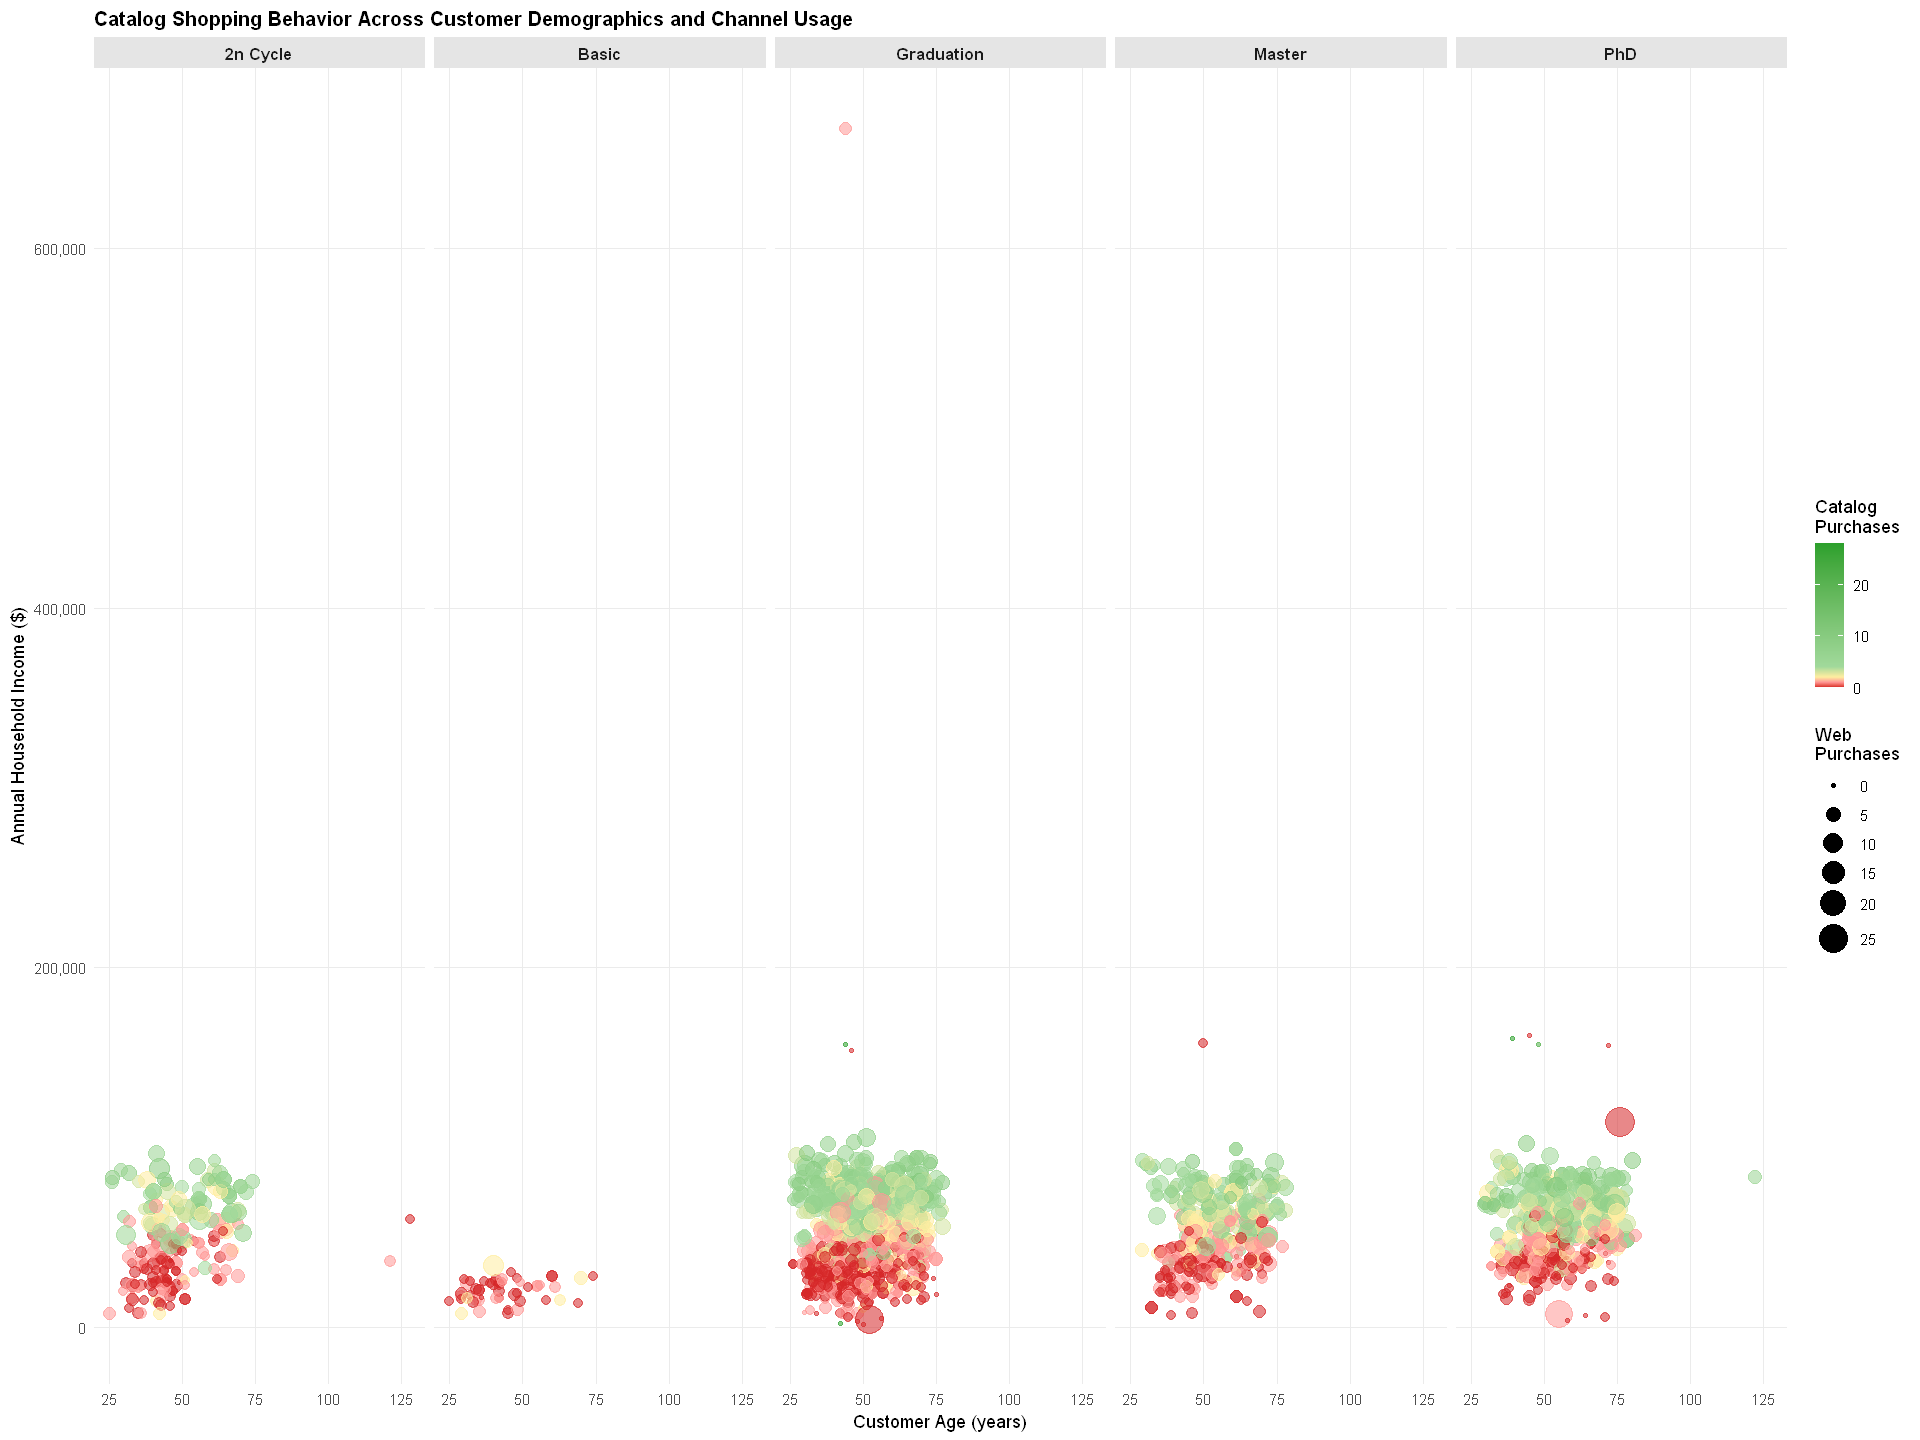

In [10]:



df <- df %>%
  mutate(
    Age = 2021 - Year_Birth,
    Total_Spending = MntWines + MntFruits + MntMeatProducts + 
                     MntFishProducts + MntSweetProducts + MntGoldProds,

  )


catalog_plot <- ggplot(df, aes(x = Age, y = Income, 
                                color = NumCatalogPurchases,
                                size = NumWebPurchases,
                                alpha = 0.7)) +
  geom_point() +
  facet_wrap(~ Education, ncol = 5) +
  scale_color_gradientn(
    colors = c("#d62728", "#ff9896", "#ffeda0", "#a1d99b", "#2ca02c"),
    values = scales::rescale(c(0, 1, 2, 4, max(df$NumCatalogPurchases))),
    name = "Catalog\nPurchases",
    limits = c(0, max(df$NumCatalogPurchases))
  ) +
  scale_size_continuous(
    range = c(1, 8),
    name = "Web\nPurchases"
  ) +
  scale_y_continuous(labels = label_comma()) +
  labs(
    title = "Catalog Shopping Behavior Across Customer Demographics and Channel Usage",
    x = "Customer Age (years)",
    y = "Annual Household Income ($)",
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 12, face = "bold"),
    plot.subtitle = element_text(size = 10, color = "gray40"),
    strip.text = element_text(size = 10, face = "bold"),
    strip.background = element_rect(fill = "gray90", color = NA),
    legend.position = "right",
    panel.grid.minor = element_blank()
  ) +
  guides(
    alpha = "none",
    color = guide_colorbar(order = 1),
    size = guide_legend(order = 2)
  )


options(repr.plot.width=16, repr.plot.height=12)


catalog_plot

### (f) AI tool disclosure:
- fixing how to read csv from github repo
- Improving wording

## (2) Computational Code and Output -- Individual Assignment 2

### a) Computation Code

Below is the implementation using LASSO and Forward Selection with a simple train/test split. Both methods use the same training data (70%) and are evaluated on the same test set (30%).

In [22]:

set.seed(301)

df_clean <- df %>%
  filter(!is.na(Income)) %>%
  mutate(
    Age = 2024 - Year_Birth,
    Education = factor(Education, levels = c("Basic", "2n Cycle", "Graduation", "Master", "PhD")),
    Marital_Status = factor(Marital_Status),
    Total_Campaigns_Accepted = AcceptedCmp1 + AcceptedCmp2 + AcceptedCmp3 + AcceptedCmp4 + AcceptedCmp5 + Response
  )


n_total <- nrow(df_clean)
n_train <- floor(0.7 * n_total)

train_indices <- sample(1:n_total, size = n_train)
train_data <- df_clean[train_indices, ]
test_data <- df_clean[-train_indices, ]


predictor_vars <- c("Age", "Income", "Education", "Marital_Status", "Kidhome", "Teenhome",
                    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", 
                    "MntSweetProducts", "MntGoldProds",
                    "NumWebPurchases", "NumStorePurchases", "NumDealsPurchases",
                    "Recency", "NumWebVisitsMonth", "Total_Campaigns_Accepted")

x_train <- model.matrix(~ . - 1, data = train_data[, predictor_vars])
y_train <- train_data$NumCatalogPurchases

x_test <- model.matrix(~ . - 1, data = test_data[, predictor_vars])
y_test <- test_data$NumCatalogPurchases

In [39]:
# METHOD 1: LASSO POISSON REGRESSION
cat("\n=== LASSO Model Training ===\n")


cv_lasso <- cv.glmnet(x_train, y_train, 
                      family = "poisson", 
                      alpha = 1, 
                      nfolds = 10,
                      type.measure = "deviance",
                      standardize = TRUE)

cat("Optimal lambda (min):", cv_lasso$lambda.min, "\n")
cat("Optimal lambda (1se):", cv_lasso$lambda.1se, "\n")


lasso_model <- glmnet(x_train, y_train, 
                      family = "poisson", 
                      alpha = 1, 
                      lambda = cv_lasso$lambda.min)


coef_lasso <- as.matrix(coef(lasso_model))
selected_lasso_vars <- rownames(coef_lasso)[coef_lasso[, 1] != 0]
selected_lasso_vars <- selected_lasso_vars[selected_lasso_vars != "(Intercept)"]

cat("\nLASSO selected", length(selected_lasso_vars), "variables:\n")
print(coef_lasso[coef_lasso[, 1] != 0, , drop = FALSE])



=== LASSO Model Training ===
Optimal lambda (min): 1.389777 
Optimal lambda (1se): 1.673991 

LASSO selected 2 variables:
                          s0
(Intercept)     0.7596160160
MntWines        0.0002479050
MntMeatProducts 0.0006877946


In [24]:
# METHOD 2: FORWARD STEPWISE SELECTION

formula_full <- as.formula(paste("NumCatalogPurchases ~", paste(predictor_vars, collapse = " + ")))


null_model <- glm(NumCatalogPurchases ~ 1, data = train_data, family = poisson(link = "log"))
full_model <- glm(formula_full, data = train_data, family = poisson(link = "log"))


forward_model <- step(null_model, 
                      scope = list(lower = null_model, upper = full_model),
                      direction = "forward",
                      trace = 0)

selected_forward_vars <- attr(terms(forward_model), "term.labels")
cat("Forward selection selected", length(selected_forward_vars), "variables:\n")
print(selected_forward_vars)

Forward selection selected 15 variables:
 [1] "MntWines"                 "NumWebVisitsMonth"       
 [3] "NumWebPurchases"          "Kidhome"                 
 [5] "MntMeatProducts"          "NumDealsPurchases"       
 [7] "MntGoldProds"             "Income"                  
 [9] "MntFishProducts"          "Education"               
[11] "Total_Campaigns_Accepted" "NumStorePurchases"       
[13] "MntSweetProducts"         "Age"                     
[15] "Teenhome"                


In [26]:

# METHOD 3: POST-LASSO (UNBIASED)
cat("\n\n=== Post-LASSO Refitting ===\n")

if (length(selected_lasso_vars) > 0) {
  # Refit with LASSO-selected variables (no penalty for unbiased estimates)
  train_lasso_df <- as.data.frame(cbind(y_train, x_train[, selected_lasso_vars, drop = FALSE]))
  colnames(train_lasso_df)[1] <- "NumCatalogPurchases"
  
  formula_postlasso <- as.formula(paste("NumCatalogPurchases ~", paste(selected_lasso_vars, collapse = " + ")))
  
  post_lasso_model <- glm(formula_postlasso, data = train_lasso_df, family = poisson(link = "log"))
  
  cat("Post-LASSO refitted with", length(selected_lasso_vars), "variables (unbiased coefficients)\n")
  print(summary(post_lasso_model))
} else {
  cat("WARNING: No variables selected by LASSO!\n")
}




=== Post-LASSO Refitting ===
Post-LASSO refitted with 2 variables (unbiased coefficients)

Call:
glm(formula = formula_postlasso, family = poisson(link = "log"), 
    data = train_lasso_df)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)     1.406e-01  2.752e-02   5.108 3.26e-07 ***
MntWines        1.113e-03  4.453e-05  24.981  < 2e-16 ***
MntMeatProducts 1.494e-03  5.904e-05  25.310  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 4691.2  on 1550  degrees of freedom
Residual deviance: 2397.1  on 1548  degrees of freedom
AIC: 5716.8

Number of Fisher Scoring iterations: 5



In [40]:
y_pred_test_lasso <- predict(lasso_model, newx = x_test, type = "response")
mae_lasso <- mean(abs(y_test - y_pred_test_lasso))
rmse_lasso <- sqrt(mean((y_test - y_pred_test_lasso)^2))


y_pred_test_forward <- predict(forward_model, newdata = test_data, type = "response")
mae_forward <- mean(abs(y_test - y_pred_test_forward))
rmse_forward <- sqrt(mean((y_test - y_pred_test_forward)^2))

if (exists("post_lasso_model")) {
  test_df <- as.data.frame(x_test[, selected_lasso_vars, drop = FALSE])
  y_pred_test_postlasso <- predict(post_lasso_model, newdata = test_df, type = "response")
  mae_postlasso <- mean(abs(y_test - y_pred_test_postlasso))
  rmse_postlasso <- sqrt(mean((y_test - y_pred_test_postlasso)^2))
  
  results_df <- data.frame(
    Model = c("LASSO (Regularized)", "Post-LASSO (Unbiased)", "Forward Selection"),
    Test_MAE = c(mae_lasso, mae_postlasso, mae_forward),
    Test_RMSE = c(rmse_lasso, rmse_postlasso, rmse_forward),
    Num_Predictors = c(length(selected_lasso_vars), length(selected_lasso_vars), length(selected_forward_vars))
  )
} else {
  results_df <- data.frame(
    Model = c("LASSO (Regularized)", "Forward Selection"),
    Test_MAE = c(mae_lasso, mae_forward),
    Test_RMSE = c(rmse_lasso, rmse_forward),
    Num_Predictors = c(length(selected_lasso_vars), length(selected_forward_vars))
  )
}

cat("\n--- Model Comparison ---\n")
print(results_df)

best_idx <- which.min(results_df$Test_MAE)
cat("\n\nBest model by Test MAE:", results_df$Model[best_idx], "\n")
cat("Test MAE:", round(results_df$Test_MAE[best_idx], 4), "\n")
cat("Predictors:", results_df$Num_Predictors[best_idx], "\n")



--- Model Comparison ---
                  Model Test_MAE Test_RMSE Num_Predictors
1   LASSO (Regularized) 1.867701  2.658452              2
2 Post-LASSO (Unbiased) 1.402591  2.169088              2
3     Forward Selection 1.261369  2.015657             15


Best model by Test MAE: Forward Selection 
Test MAE: 1.2614 
Predictors: 15 


### b) Visualization


In [41]:
cat("\n--- Model Comparison ---\n")
print(results_df)


--- Model Comparison ---
                  Model Test_MAE Test_RMSE Num_Predictors
1   LASSO (Regularized) 1.867701  2.658452              2
2 Post-LASSO (Unbiased) 1.402591  2.169088              2
3     Forward Selection 1.261369  2.015657             15


### c) Interpretation
Forward selection achieved the best test set performance (MAE = 1.26) using 15 predictors, while LASSO selected only 2 variables (wines and meat spending) with MAE = 1.87. Post-LASSO refitting improved accuracy to MAE = 1.40 by removing coefficient shrinkage bias. The results demonstrate a clear trade-off between model parsimony and predictive accuracy. All models successfully identified spending patterns, particularly on wines and meat products, as key drivers of catalog purchases.